<a href="https://colab.research.google.com/github/jeandirel/NLP/blob/main/ForcastARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the dataset from Yahoo Finance
ticker = 'AAPL'  # Apple Inc.
data = yf.download(ticker, start='2021-01-01', end='2024-07-01')

# Affichage des premières lignes pour vérifier
data.head()


/tmp/ipython-input-1-1341174087.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2021-01-01', end='2024-07-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,126.239700,130.336805,123.654619,130.249014,143301900
2021-01-05,127.800476,128.512603,125.283680,125.732417,97664900
2021-01-06,123.498528,127.839515,123.283916,124.591092,155088000
2021-01-07,127.712700,128.405313,124.727667,125.215418,109578200
2021-01-08,128.815018,129.380811,127.039597,129.185698,105158200


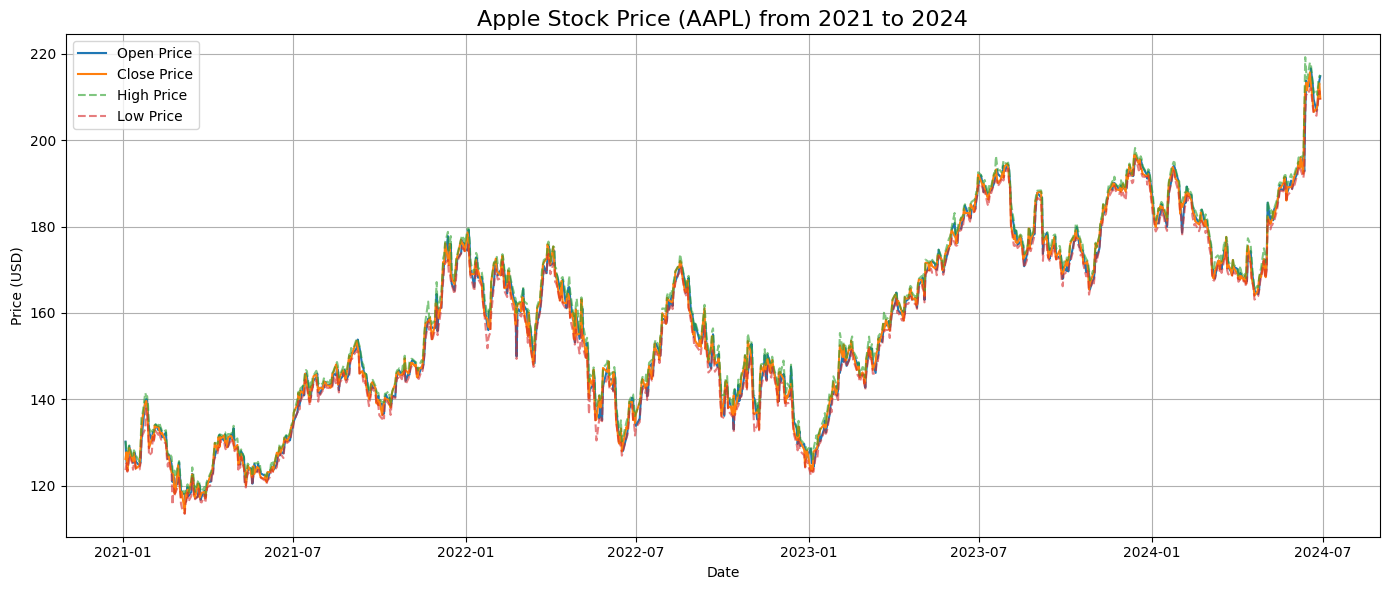

In [2]:
# Définir la taille de la figure
plt.figure(figsize=(14, 6))

# Tracer les prix
plt.plot(data.index, data['Open'], label='Open Price')
plt.plot(data.index, data['Close'], label='Close Price')
plt.plot(data.index, data['High'], label='High Price', linestyle='--', alpha=0.6)
plt.plot(data.index, data['Low'], label='Low Price', linestyle='--', alpha=0.6)

# Ajouter des éléments de mise en page
plt.title('Apple Stock Price (AAPL) from 2021 to 2024', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Afficher le graphique
plt.show()


In [4]:
close_prices = data['Close']

model = ARIMA(close_prices, order=(5, 1, 1))  # p=5, d=1, q=2

# 5. Ajustement du modèle
model_fit = model.fit()

# 6. Afficher le résumé du modèle
print(model_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  877
Model:                 ARIMA(5, 1, 1)   Log Likelihood               -2095.933
Date:                Mon, 21 Jul 2025   AIC                           4205.867
Time:                        09:17:13   BIC                           4239.294
Sample:                             0   HQIC                          4218.653
                                - 877                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0081      6.607      0.001      0.999     -12.941      12.957
ar.L2         -0.0462      0.115     -0.402      0.688      -0.271       0.179
ar.L3         -0.0151      0.308     -0.049      0.9

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


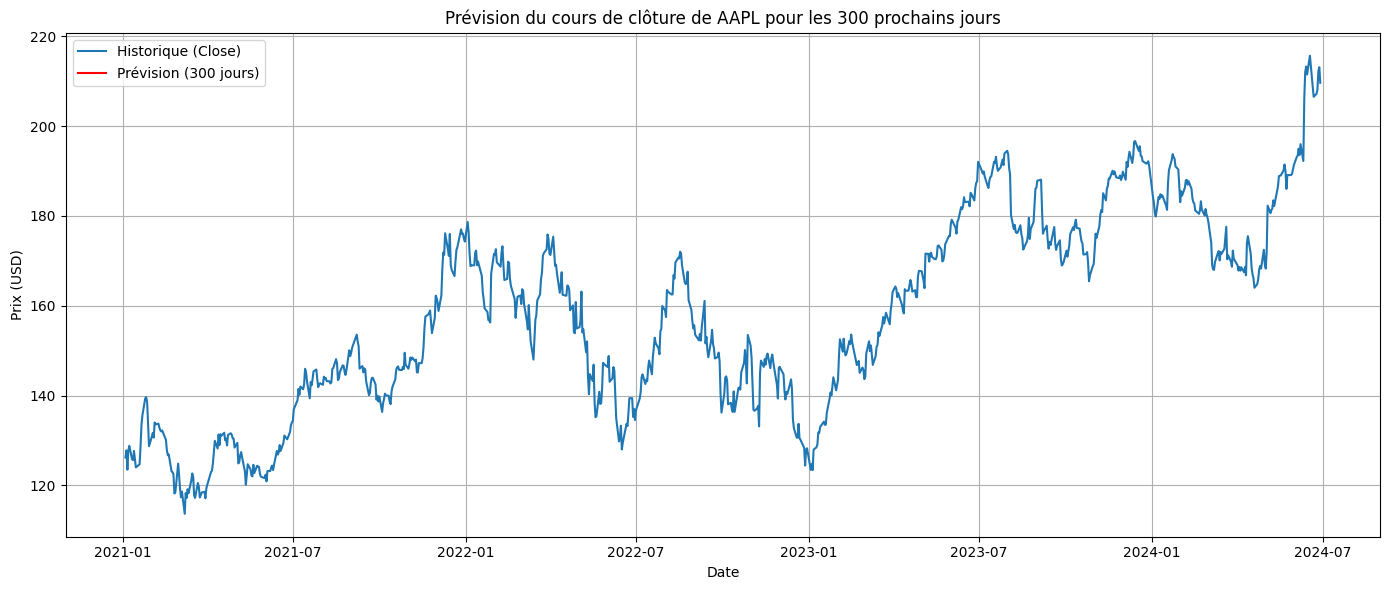

In [5]:
forecast = model_fit.forecast(steps=300)

# Créer une nouvelle série de dates pour les prédictions
last_date = close_prices.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=300, freq='B')  # jours ouvrés

# Mettre en forme les prédictions
forecast_series = pd.Series(forecast, index=forecast_index)

# Tracer les résultats
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label='Historique (Close)')
plt.plot(forecast_series, label='Prévision (300 jours)', color='red')
plt.title('Prévision du cours de clôture de AAPL pour les 300 prochains jours')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


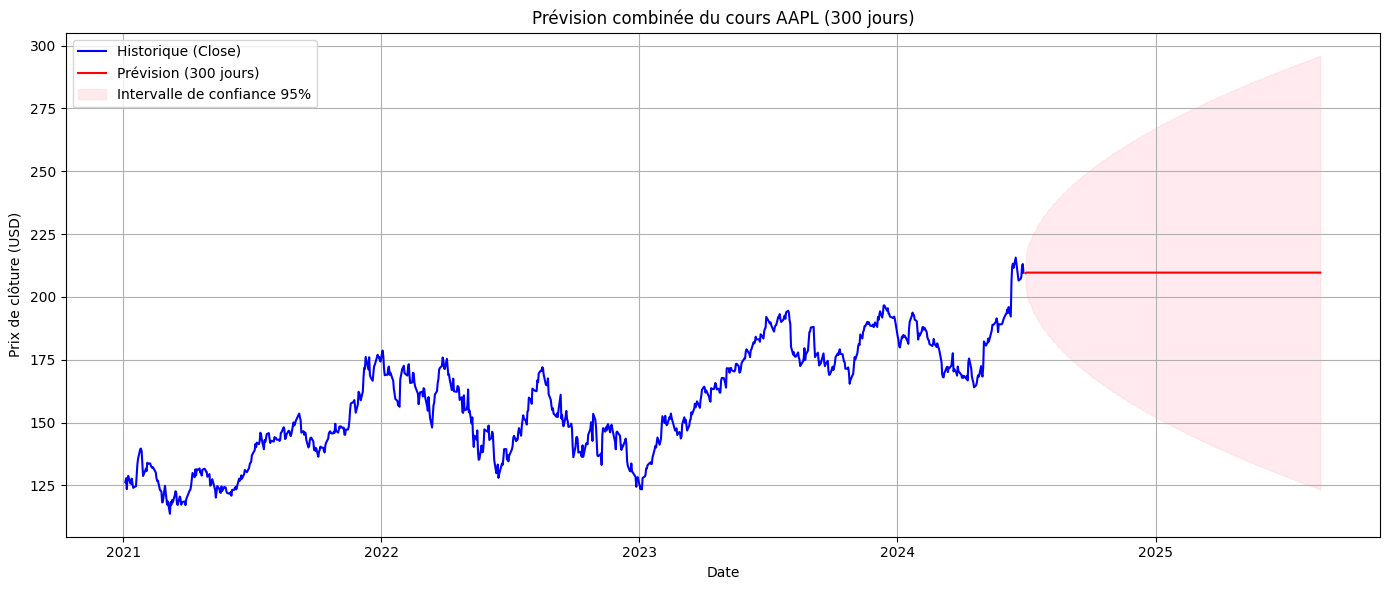

In [6]:
forecast_result = model_fit.get_forecast(steps=300)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Générer les dates futures (jours ouvrés)
last_date = close_prices.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=300, freq='B')

# Aligner les séries
forecast_mean.index = forecast_index
conf_int.index = forecast_index

# Tracer l'historique + prévision + intervalles de confiance
plt.figure(figsize=(14, 6))
plt.plot(close_prices, label='Historique (Close)', color='blue')
plt.plot(forecast_mean, label='Prévision (300 jours)', color='red')

# Tracer l'intervalle de confiance
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalle de confiance 95%')

plt.title('Prévision combinée du cours AAPL (300 jours)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-7-2559451345.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01', periods=24, freq='M'),  # freq='M' pour mois fin de mois


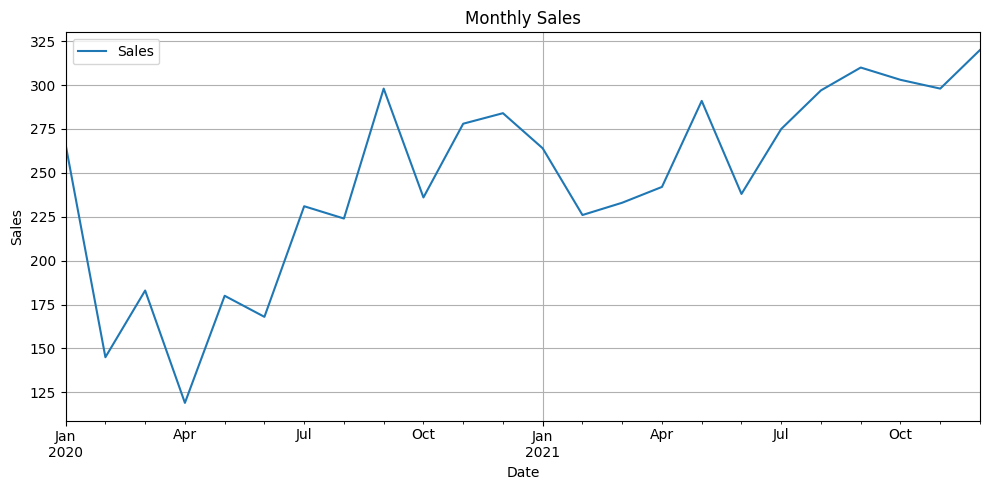

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Exemple de données mensuelles de ventes
data = {
    'Month': pd.date_range(start='2020-01', periods=24, freq='M'),  # freq='M' pour mois fin de mois
    'Sales': [266, 145, 183, 119, 180, 168, 231, 224, 298, 236, 278, 284,
              264, 226, 233, 242, 291, 238, 275, 297, 310, 303, 298, 320]
}

# Créer un DataFrame et définir l'index temporel
df = pd.DataFrame(data).set_index('Month')

# Tracer la série temporelle
df.plot(title='Monthly Sales', figsize=(10, 5))
plt.ylabel('Sales')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
from statsmodels.tsa.arima.model import ARIMA

# Créer et entraîner le modèle ARIMA
model = ARIMA(df['Sales'], order=(1, 1, 1))  # Tu peux ajuster (p, d, q)
modelfit = model.fit()

# Afficher le résumé du modèle
print(modelfit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   24
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -114.475
Date:                Mon, 21 Jul 2025   AIC                            234.950
Time:                        09:33:22   BIC                            238.356
Sample:                    01-31-2020   HQIC                           235.806
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9700      0.039    -24.800      0.000      -1.047      -0.893
ma.L1          0.6915      0.204      3.391      0.001       0.292       1.091
sigma2      1168.0438    476.210      2.453      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


/tmp/ipython-input-13-2536276557.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01', periods=24, freq='M'),
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-13-2536276557.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=last_date 

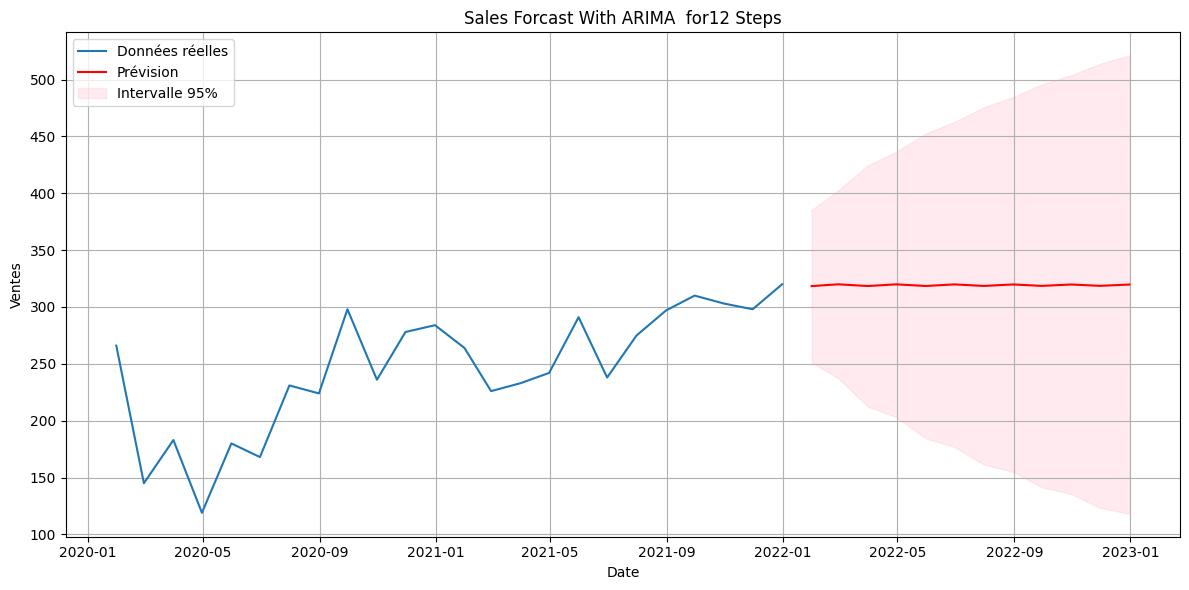

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Tes données de ventes
data = {
    'Month': pd.date_range(start='2020-01', periods=24, freq='M'),
    'Sales': [266, 145, 183, 119, 180, 168, 231, 224, 298, 236, 278, 284,
              264, 226, 233, 242, 291, 238, 275, 297, 310, 303, 298, 320]
}
df = pd.DataFrame(data).set_index('Month')

# --- 🔮 Étapes pour modélisation ARIMA ---
# Choisir la durée de la prévision (ex. 12 mois)
forecast_steps = 15  # ➕ mettre 6 pour 6 mois, 24 pour 2 ans, etc.

# Créer et entraîner le modèle
model = ARIMA(df['Sales'], order=(1, 1, 1))  # Tu peux ajuster les (p,d,q)
model_fit = model.fit()

# Faire la prévision
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Générer les dates futures
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='M')
forecast.index = forecast_index
conf_int.index = forecast_index

# --- 📈 Tracer la série réelle + prévision + intervalle ---
plt.figure(figsize=(12, 6))
plt.plot(df['Sales'], label='Données réelles')
plt.plot(forecast, label='Prévision', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Interval 95%')
plt.title(f'Sales Forcast With ARIMA  for {forecast_steps} Steps')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
